Found 500 images belonging to 2 classes.
Found 124 images belonging to 2 classes.


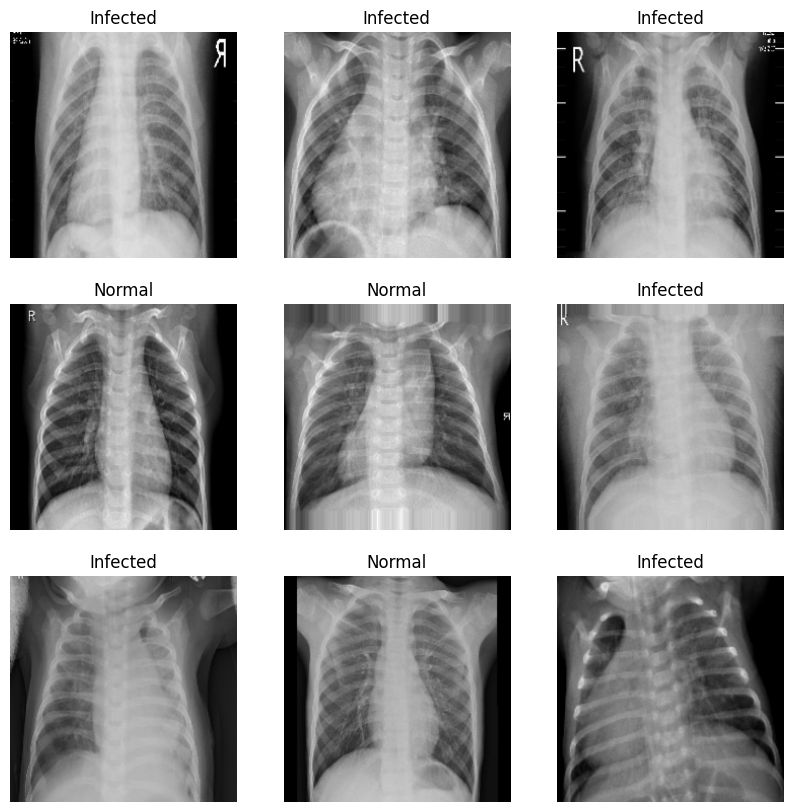

🚀 Starting Training...
Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 134s 8s/step - accuracy: 0.5488 - loss: 0.7694 - val_accuracy: 0.3710 - val_loss: 0.7591
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 139s 9s/step - accuracy: 0.4634 - loss: 0.8203 - val_accuracy: 0.4597 - val_loss: 0.6896
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 145s 9s/step - accuracy: 0.5480 - loss: 0.7136 - val_accuracy: 0.6290 - val_loss: 0.6425
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 121s 8s/step - accuracy: 0.6164 - loss: 0.6583 - val_accuracy: 0.6290 - val_loss: 0.6409
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 121s 8s/step - accuracy: 0.6246 - loss: 0.6424 - val_accuracy: 0.6290 - val_loss: 0.6475
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 121s 8s/step - accuracy: 0.6047 - loss: 0.6642 - val_accuracy: 0.6371 - val_loss: 0.6228
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 121s 8s/step - accuracy: 0.6402 - loss: 0.6206 - val_accuracy: 0.6290 - val_loss: 0.6145
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 121s 8s/step - accuracy: 0.6501 - loss: 0.6238 - v

✅ Model saved as my_pneumonia_model.h5


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

# --- STEP 1: SET YOUR COPIED PATH HERE ---
data_path = '/content/chest-xray-pneumonia/chest_xray/test' # PASTE YOUR COPIED PATH HERE

# --- STEP 2: DATA PREPARATION ---
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2, # 80% Train, 20% Test
    horizontal_flip=True,
    zoom_range=0.2
)

train_gen = datagen.flow_from_directory(
    data_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    data_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

# --- STEP 3: VISUALIZE (To check if it's working) ---
images, labels = next(train_gen)
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title("Infected" if labels[i] == 1 else "Normal")
    plt.axis("off")
plt.show()

# --- STEP 4: BUILD RESNET-50 ---
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# --- STEP 5: TRAIN ---
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("🚀 Starting Training...")
history = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen
)

# --- STEP 6: SAVE ---
model.save('my_pneumonia_model.h5')
print("✅ Model saved as my_pneumonia_model.h5")

Total images in your folders: 624
Images used for Training: 500
Images used for Validation: 124


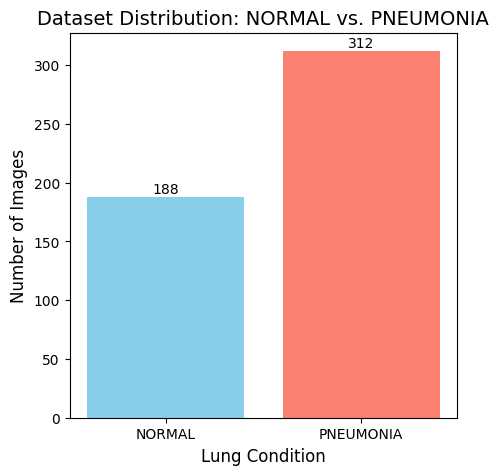

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Get the counts from the generator
# class_indices tells us which folder is 0 and which is 1
labels = train_gen.class_indices
# classes is a list of labels for every image (e.g., [0, 0, 1, 0...])
class_counts = train_gen.classes

# 2. Count how many of each
normal_count = np.sum(class_counts == labels['NORMAL'])
infected_count = np.sum(class_counts == labels['PNEUMONIA'])

# 3. Create the Bar Graph
categories = ['NORMAL', 'PNEUMONIA']
counts = [normal_count, infected_count]

plt.figure(figsize=(5, 5))
bars = plt.bar(categories, counts, color=['skyblue', 'salmon'])

total_train = train_gen.samples
total_val = val_gen.samples
total_data = total_train + total_val

print(f"Total images in your folders: {total_data}")
print(f"Images used for Training: {total_train}")
print(f"Images used for Validation: {total_val}")

# Add some styling
plt.xlabel('Lung Condition', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('Dataset Distribution: NORMAL vs. PNEUMONIA', fontsize=14)

# Add the count numbers on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, yval, ha='center', va='bottom')

plt.show()